In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Colab Notebooks/Mate academy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/Mate academy


In [ ]:
countries = pd.read_csv("countries.csv")
countries["alpha-2"]= countries["alpha-2"].fillna("Unknown")
countries["region"]= countries["region"].fillna("Unknown")
countries["sub-region"]= countries["sub-region"].fillna("Unknown")
countries.head()



,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
events = pd.read_csv("events.csv")
events = events.dropna(subset=["Country Code"])
events["Units Sold"] = events["Units Sold"].fillna(0)

events["Order Date"]= pd.to_datetime(events["Order Date"], errors="coerce")
events["Ship Date"]= pd.to_datetime(events["Ship Date"], errors="coerce")
events["Sales Channel"] = events["Sales Channel"].str.strip().str.capitalize()

events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79
5,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96


In [ ]:
products = pd.read_csv("products.csv")
products.head()


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


# Доля пропусків перевищує 0.004% тому пропущені текстові дані я заповнила як "Unknown", рядки з пропусками в Country Code я видалила, а пропуски в "Units Sold" я заповнила нулями
# Дублікатів не виявлено

In [ ]:
df = countries.merge(events, left_on="alpha-3", right_on="Country Code", how="left")
df = df.merge(products, left_on="Product ID", right_on="id", how="left")

df.drop(columns=["alpha-2", "alpha-3", "Country Code", "Product ID", "id"], inplace=True)

df.head()

,name,region,sub-region,Order ID,Order Date,Ship Date,Order Priority,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type
0,Afghanistan,Asia,Southern Asia,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,Åland Islands,Europe,Northern Europe,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,Europe,Southern Europe,152191388.0,2012-05-18,2012-06-22,L,Offline,5669.0,255.28,159.42,Baby Food
3,Albania,Europe,Southern Europe,208238399.0,2015-08-29,2015-10-15,L,Offline,1224.0,437.20,263.33,Cosmetics
4,Albania,Europe,Southern Europe,246922719.0,2015-07-13,2015-07-29,H,Online,8775.0,651.21,524.96,Office Supplies


In [ ]:
print(f"Загальна кількість замовлень: {df["Order ID"].nunique()}")
print(f"Загальний прибуток: {((df["Unit Price"]- df["Unit Cost"]) * df["Units Sold"]).sum()}")
print(f"Загальний дохід: {(df["Unit Price"] * df["Units Sold"]).sum()}")
print(f"Загальна кількість охоплених країн: {df["name"].nunique()}")
print(f"Загальна кількість категорій товарів: {df["item_type"].nunique()}")
print(f"Середній розмір замовлення: {df["Units Sold"].mean()}")



Загальна кількість замовлень: 1248
Загальний прибуток: 473709035.06
Загальний дохід: 1598983761.26
Загальна кількість охоплених країн: 249
Загальна кількість категорій товарів: 12
Середній розмір замовлення: 4945.249198717948


In [ ]:
df["Revenue"]= df["Unit Price"] * df["Units Sold"]
df["Cost"] = df["Unit Cost"] * df["Units Sold"]
df["Profit"]= df["Revenue"]- df["Cost"]

In [ ]:
# Аналіз в розрізі категорій товарів та візуалізація
by_categories = df.groupby("item_type")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().sort_values("Revenue", ascending=False)
print(by_categories)

                      Revenue          Cost       Profit  Units Sold
item_type                                                           
Office Supplies  3.786662e+08  3.052543e+08  73411976.25    581481.0
Household        2.788744e+08  2.097140e+08  69160454.84    417308.0
Cosmetics        2.213054e+08  1.332945e+08  88010907.56    506188.0
Meat             2.013398e+08  1.740421e+08  27297727.60    477233.0
Baby Food        1.338344e+08  8.357833e+07  50256042.90    524265.0
Cereal           9.467672e+07  5.390175e+07  40774964.94    460266.0
Vegetables       8.203849e+07  4.842113e+07  33617356.30    532510.0
Snacks           6.921349e+07  4.420083e+07  25012661.94    453621.0
Clothes          6.330732e+07  2.076258e+07  42544746.72    579313.0
Personal Care    4.334632e+07  3.005550e+07  13290821.60    530360.0
Beverages        2.742567e+07  1.837433e+07   9051339.06    577991.0
Fruits           4.955490e+06  3.675454e+06   1280035.35    531135.0


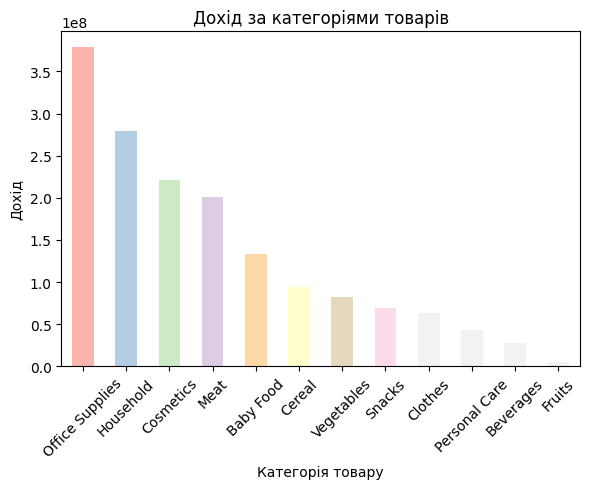

In [ ]:
plt.figure(figsize=(6,5))
colors = plt.cm.Pastel1(range(20))
by_categories["Revenue"].plot(kind="bar", color=colors)
plt.title("Дохід за категоріями товарів")
plt.xlabel("Категорія товару")
plt.ylabel("Дохід")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

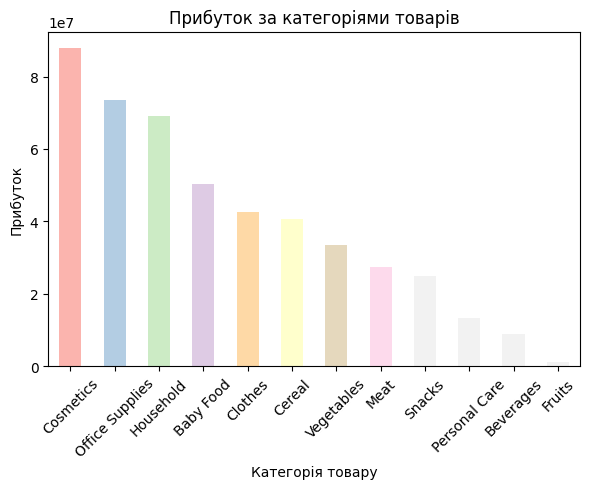

In [ ]:
plt.figure(figsize=(6,5))
colors = plt.cm.Pastel1(range(20))
by_categories.sort_values("Profit", ascending=False)["Profit"].plot(kind="bar", color=colors)
plt.title("Прибуток за категоріями товарів")
plt.xlabel("Категорія товару")
plt.ylabel("Прибуток")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

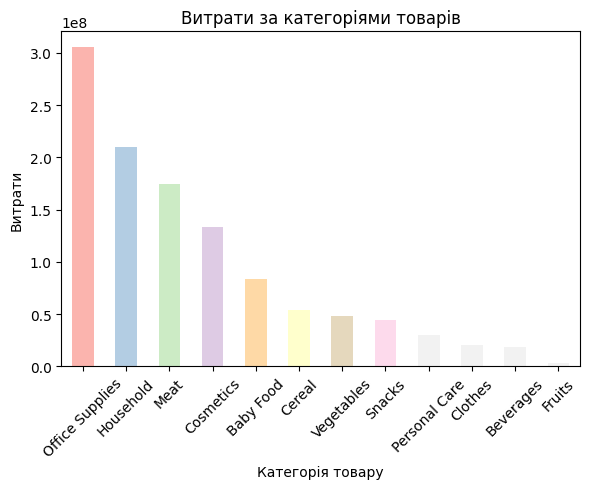

In [ ]:
plt.figure(figsize=(6,5))
colors = plt.cm.Pastel1(range(20))
by_categories.sort_values("Cost", ascending=False)["Cost"].plot(kind="bar", color=colors)
plt.title("Витрати за категоріями товарів")
plt.xlabel("Категорія товару")
plt.ylabel("Витрати")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

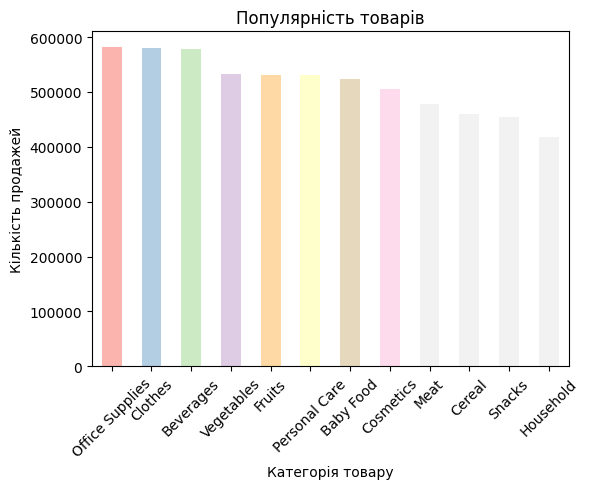

In [ ]:
plt.figure(figsize=(6,5))
colors = plt.cm.Pastel1(range(20))
by_categories.sort_values("Units Sold", ascending=False)["Units Sold"].plot(kind="bar", color=colors)
plt.title("Популярність товарів")
plt.xlabel("Категорія товару")
plt.ylabel("Кількість продажей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Аналіз в розрізі категорій географії (країн, регіонів)
by_geography_country = df.groupby("name")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().sort_values("Revenue", ascending=False)
print(by_geography_country)

by_geography_region = df.groupby("region")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().sort_values("Revenue", ascending=False)
print(by_geography_region)

                            Revenue         Cost       Profit  Units Sold
name                                                                     
Czech Republic          53543932.14  39908338.36  13635593.78    142446.0
Ukraine                 53252317.54  38447391.80  14804925.74    164577.0
Bosnia and Herzegovina  50117508.49  36859905.72  13257602.77    153545.0
Macedonia               49222085.25  35537985.30  13684099.95    203078.0
San Marino              47883708.48  34090715.67  13792992.81    192228.0
...                             ...          ...          ...         ...
Western Sahara                 0.00         0.00         0.00         0.0
Yemen                          0.00         0.00         0.00         0.0
Zambia                         0.00         0.00         0.00         0.0
Zimbabwe                       0.00         0.00         0.00         0.0
Åland Islands                  0.00         0.00         0.00         0.0

[249 rows x 4 columns]
              

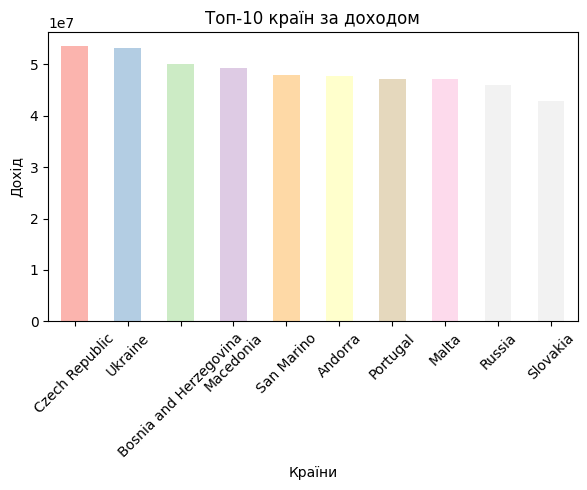

In [ ]:
plt.figure(figsize=(6,5))
colors = plt.cm.Pastel1(range(10))
by_geography_country.sort_values("Revenue", ascending=False).head(10)["Revenue"].plot(kind="bar", color=colors)
plt.title("Топ-10 країн за доходом")
plt.xlabel("Країни")
plt.ylabel("Дохід")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

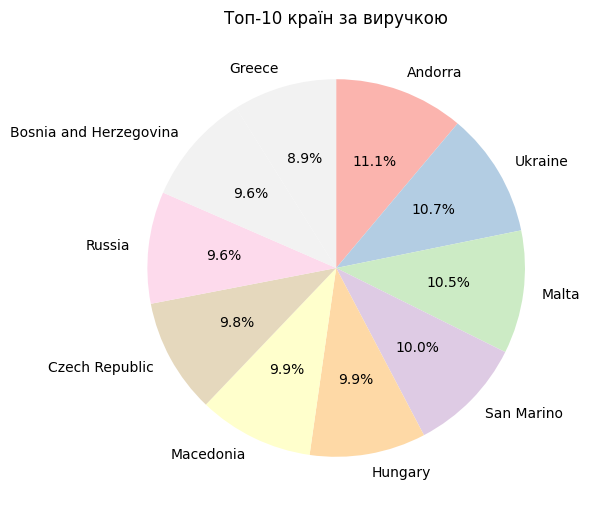

In [ ]:
plt.figure(figsize=(6,6))
top10 = by_geography_country.sort_values("Profit", ascending=False).head(10)
colors = plt.cm.Pastel1(range(10))
plt.pie(top10["Profit"], labels=top10.index, autopct='%1.1f%%', startangle=90,counterclock=False, colors=colors)
plt.title("Топ-10 країн за виручкою")
plt.tight_layout()
plt.show()

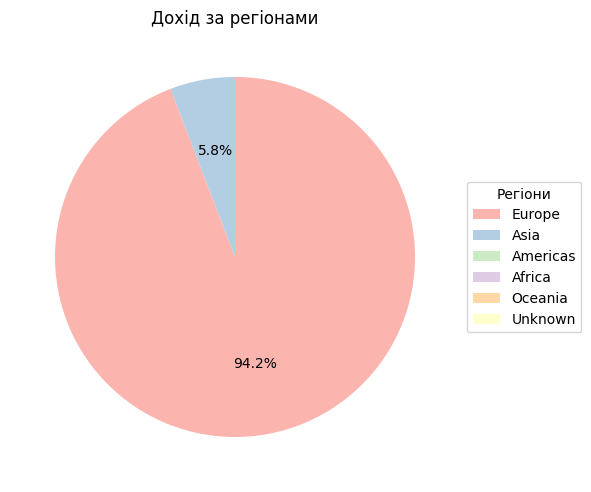

In [ ]:
plt.figure(figsize=(6,6))
by_region = by_geography_region["Revenue"].sort_values(ascending=False)
colors = plt.cm.Pastel1(range(len(by_region)))
def autopct_filter(pct):
    return f'{pct:.1f}%' if pct > 1 else ''
plt.pie(by_region, autopct=autopct_filter, startangle=90,counterclock=False, colors=colors)
plt.title("Дохід за регіонами")
plt.legend(by_region.index, title="Регіони",loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

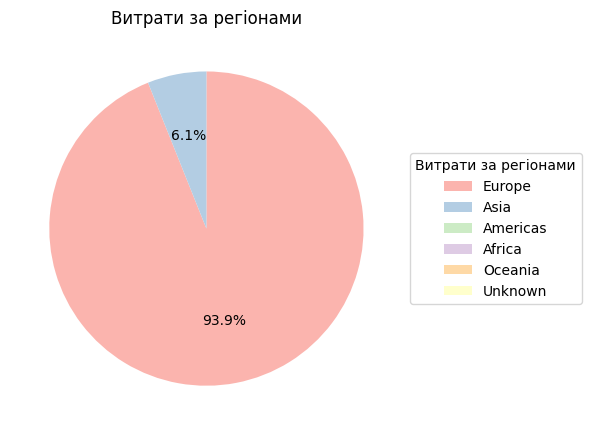

In [ ]:
plt.figure(figsize=(6,6))
by_geography= by_geography_region["Cost"].sort_values(ascending=False)
colors = plt.cm.Pastel1(range(len(by_geography)))
def autopct_filter(pct):
    return f'{pct:.1f}%' if pct > 1 else ''
plt.pie(by_geography, autopct=autopct_filter, startangle=90,counterclock=False, colors=colors)
plt.title("Витрати за регіонами")
plt.legend(by_geography.index, title="Витрати за регіонами",loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [ ]:
# Аналіз в розрізі каналів продажу (онлайн або офлайн)
by_sales_channel = df.groupby("Sales Channel")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().sort_values("Revenue", ascending=False)
print(by_sales_channel)

                    Revenue          Cost        Profit  Units Sold
Sales Channel                                                      
Offline        8.100305e+08  5.715191e+08  2.385113e+08   3113412.0
Online         7.889533e+08  5.537556e+08  2.351977e+08   3058259.0


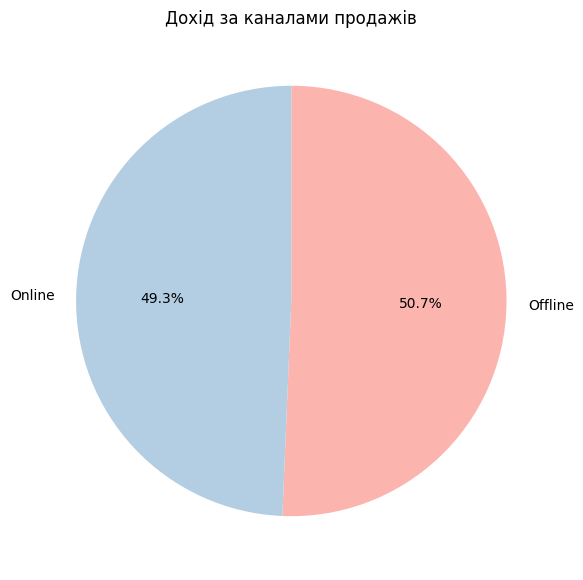

In [ ]:
plt.figure(figsize=(6,6))
by_channel= by_sales_channel["Revenue"].sort_values(ascending=False)
colors = plt.cm.Pastel1(range(len(by_channel)))
plt.pie(by_channel, labels=by_channel.index, autopct='%1.1f%%', startangle=90,counterclock=False, colors=colors)
plt.title("Дохід за каналами продажів")
plt.tight_layout()
plt.show()

# Різниця між каналами продажу невелика, але в офлайн форматі все ж дохід є вищим

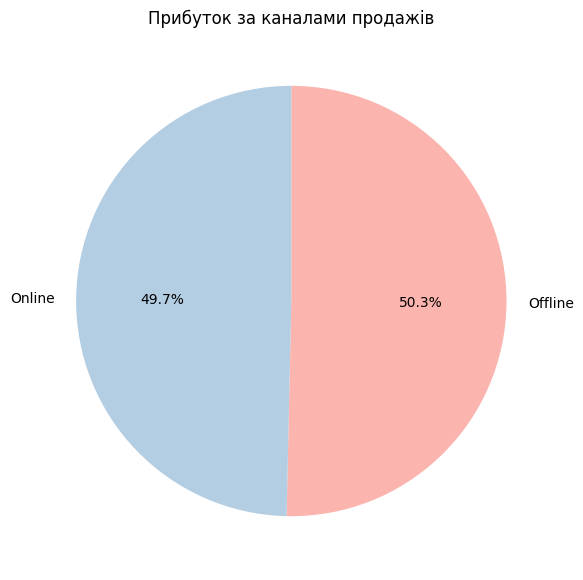

In [ ]:
plt.figure(figsize=(6,6))
profit_by_channel= by_sales_channel["Profit"].sort_values(ascending=False)
colors = plt.cm.Pastel1(range(len(profit_by_channel)))
plt.pie(profit_by_channel, labels=profit_by_channel.index, autopct='%1.1f%%', startangle=90,counterclock=False, colors=colors)
plt.title("Прибуток за каналами продажів")
plt.tight_layout()
plt.show()

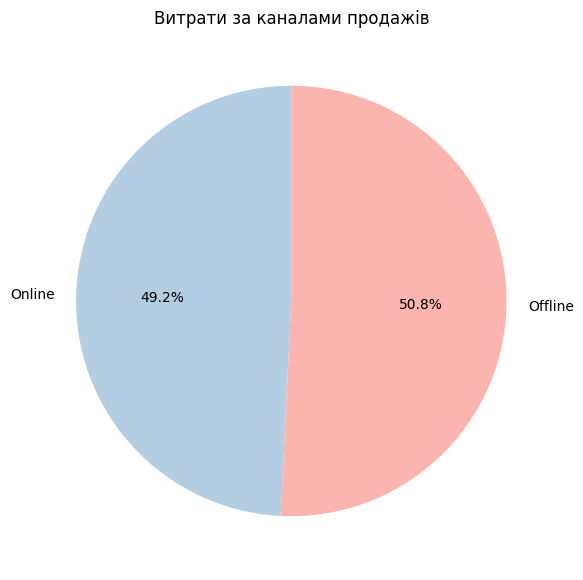

In [ ]:
plt.figure(figsize=(6,6))
cost_by_channel= by_sales_channel["Cost"].sort_values(ascending=False)
colors = plt.cm.Pastel1(range(len(cost_by_channel)))
plt.pie(cost_by_channel, labels=cost_by_channel.index, autopct='%1.1f%%', startangle=90,counterclock=False, colors=colors)
plt.title("Витрати за каналами продажів")
plt.tight_layout()
plt.show()

In [ ]:
# Інтервал часу між замовленням та його відвантаженням
df["interval"] = df["Ship Date"] - df["Order Date"]
df["interval"] = df["interval"].dt.days

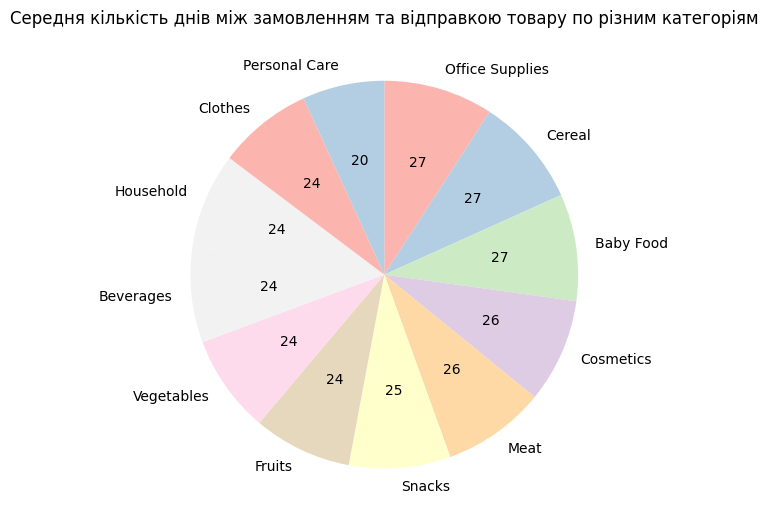

In [ ]:
plt.figure(figsize=(6,6))
category_interval= df.groupby("item_type")["interval"].mean().sort_values(ascending=False)
colors = plt.cm.Pastel1(range(10))
def format_days(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{absolute}"
plt.pie(category_interval, labels=category_interval.index, startangle=90,counterclock=False, colors=colors, autopct=lambda pct: format_days(pct, category_interval))
plt.title("Середня кількість днів між замовленням та відправкою товару по різним категоріям")
plt.tight_layout()
plt.show()

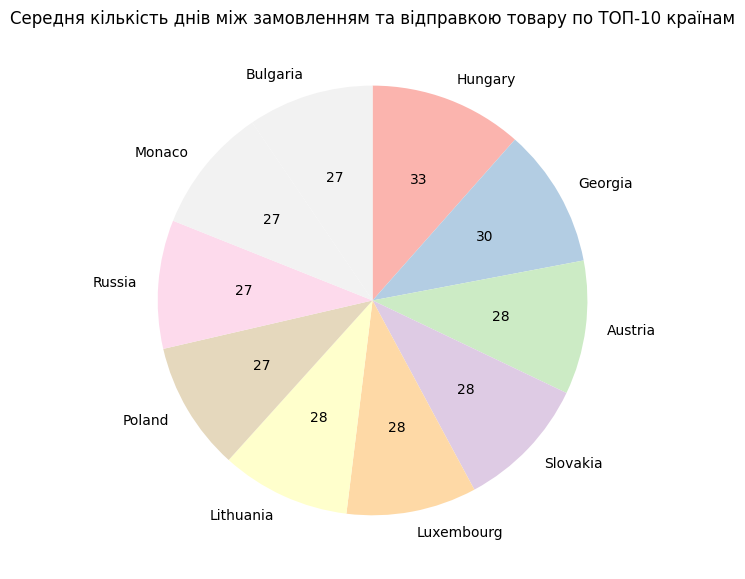

In [ ]:
plt.figure(figsize=(6,6))
average_delivery_by_countries = df.groupby("name")["interval"].mean().sort_values(ascending=False).head(10).dropna()

colors = plt.cm.Pastel1(range(len(average_delivery_by_countries)))
def format_days(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{absolute}"

plt.pie(average_delivery_by_countries, labels=average_delivery_by_countries.index, startangle=90,counterclock=False, colors=colors, autopct=lambda pct: format_days(pct, average_delivery_by_countries))
plt.title("Середня кількість днів між замовленням та відправкою товару по ТОП-10 країнам")
plt.tight_layout()
plt.show()

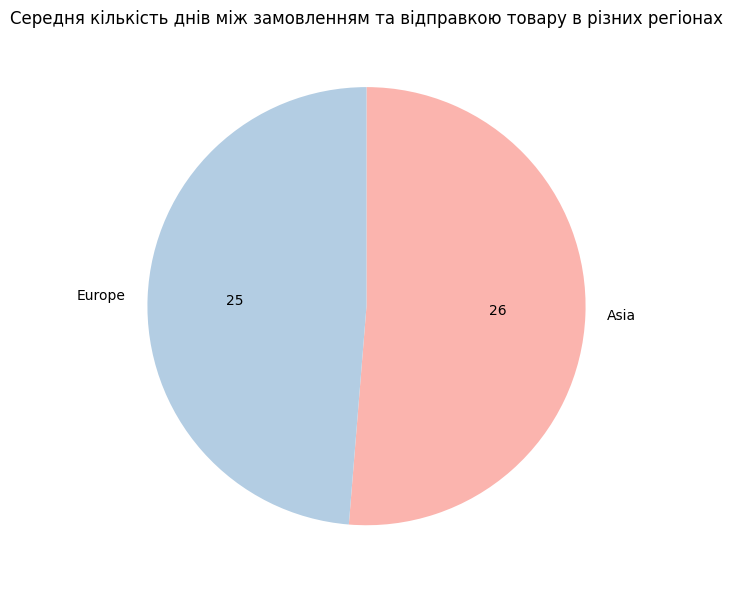

In [ ]:
plt.figure(figsize=(6, 6))
interval= df.groupby("region")["interval"].mean().sort_values(ascending=False)
interval = interval.dropna()
colors = plt.cm.Pastel1(range(len(interval)))
def format_days(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{absolute}"
plt.pie(interval, labels=interval.index, startangle=90, counterclock=False, colors=colors, autopct=lambda pct: format_days(pct, interval))
plt.title("Середня кількість днів між замовленням та відправкою товару в різних регіонах")
plt.tight_layout()
plt.show()

In [ ]:
corr = df["Profit"].corr(df["interval"])
print(corr)

0.06145484643682224


# Кореляція 0.061 - це дуже слабкий позитивний зв'язок. Тобто прибуток практично не залежить від часу відвантаження

<function matplotlib.pyplot.show(close=None, block=None)>

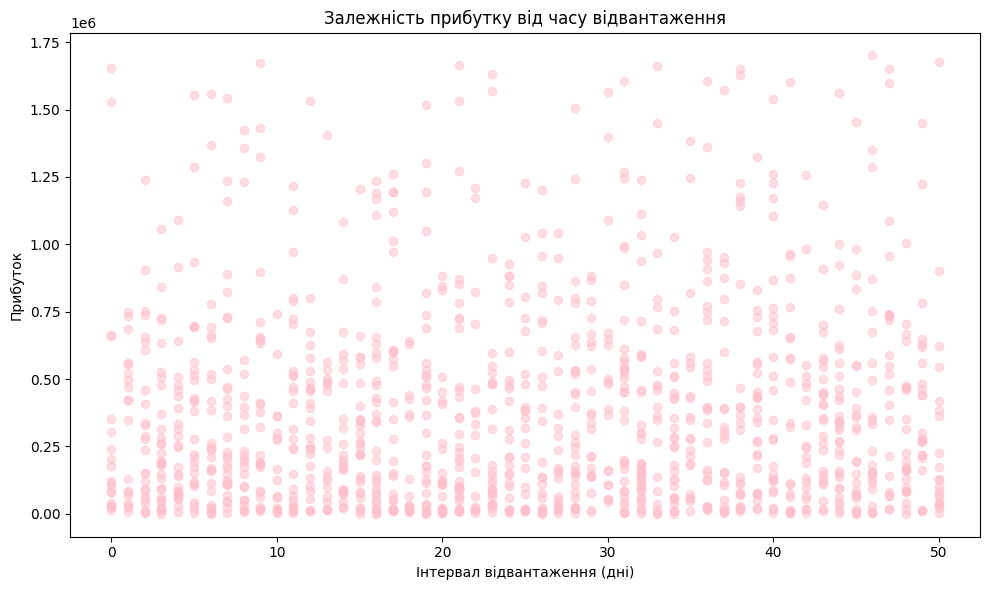

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["interval"], df["Profit"], alpha=0.5, color="pink")
plt.title("Залежність прибутку від часу відвантаження")
plt.xlabel("Інтервал відвантаження (дні)")
plt.ylabel("Прибуток")
plt.tight_layout()
plt.show

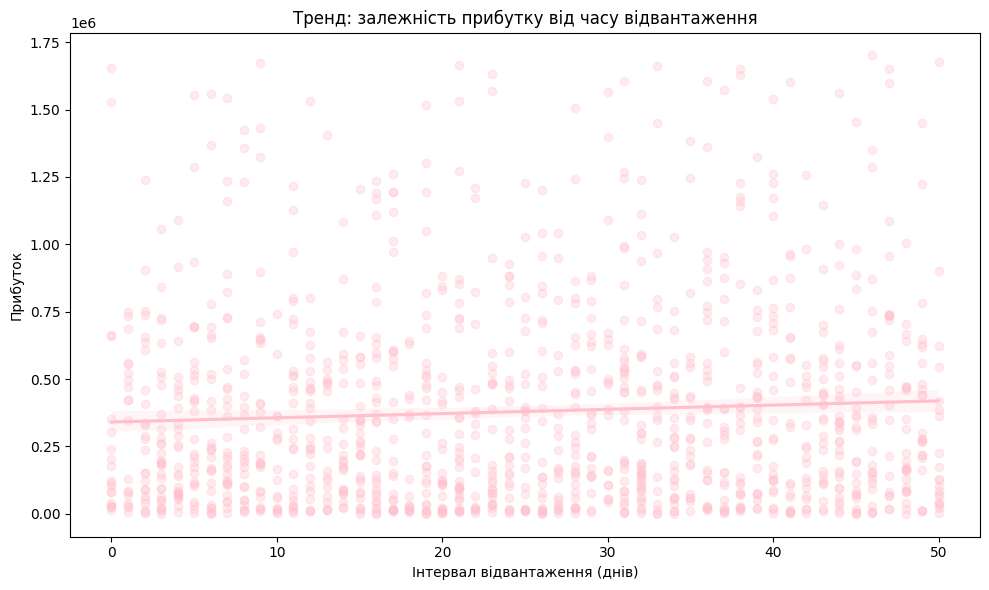

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(x="interval", y="Profit", data=df, scatter_kws={"alpha":0.3}, color="pink")
plt.title("Тренд: залежність прибутку від часу відвантаження")
plt.xlabel("Інтервал відвантаження (днів)")
plt.ylabel("Прибуток")
plt.tight_layout()
plt.show()

# Велика концентрація точок знизу, це означає, що більшість замовлень мають малий прибуток. Лінія лінійної регресії майже горизонтальна, це означає, що немає помітного тренду або залежності між часом відвантаження та прибутком

In [ ]:
df["Year"] = df["Order Date"].dt.to_period("Y").astype(str)

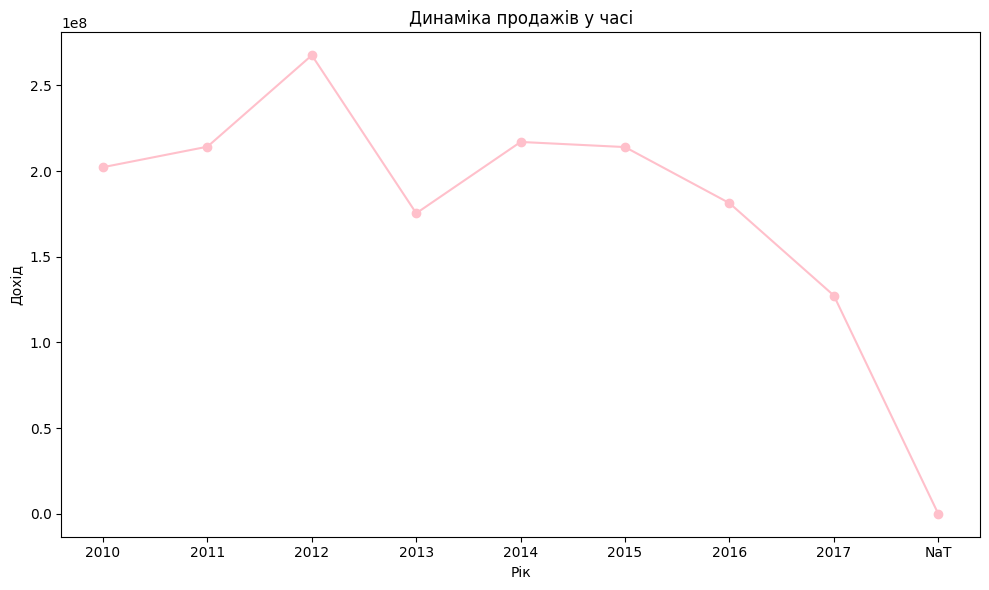

In [ ]:
plt.figure(figsize=(10,6))
sales_over_time = (df.groupby("Year")["Revenue"].sum().reset_index())
plt.plot(sales_over_time["Year"], sales_over_time["Revenue"], color="pink", marker="o")
plt.title("Динаміка продажів у часі")
plt.xlabel("Рік")
plt.ylabel("Дохід")
plt.tight_layout()
plt.show()

# Найвищі показники доходу були у 2012 році, після цього показники мають тенденцію спадання

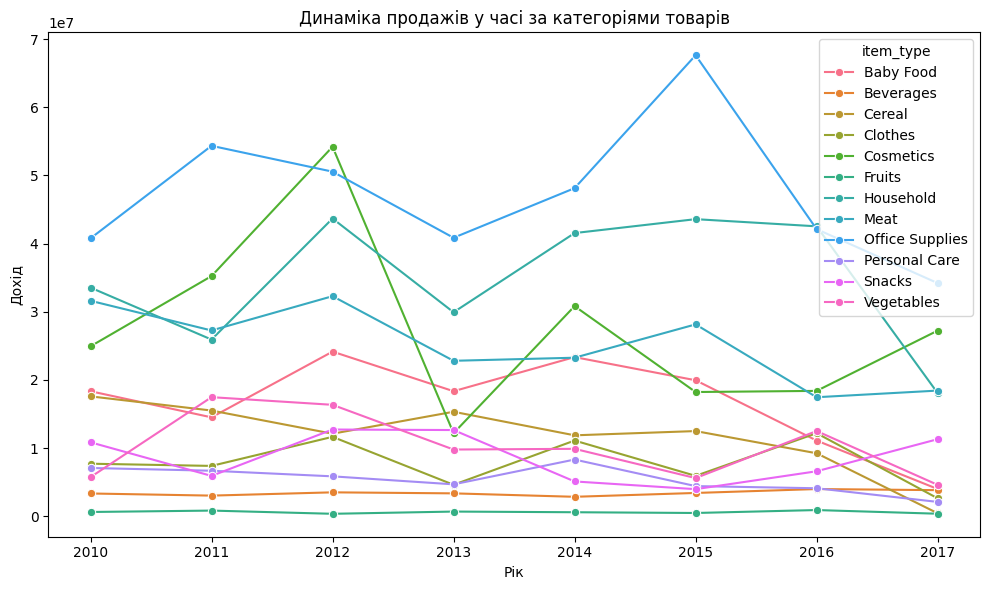

In [ ]:
sales_over_time_category = (df.groupby(["Year", "item_type"])["Revenue"].sum().reset_index())
plt.figure(figsize=(10,6))
sns.lineplot(data=sales_over_time_category, x="Year", y="Revenue", hue="item_type", marker="o")
plt.title("Динаміка продажів у часі за категоріями товарів")
plt.xlabel("Рік")
plt.ylabel("Дохід")
plt.tight_layout()
plt.show()

# Найпопулярнішими товарами у магазині є офісні приладдя, вони ж приносять найбільше доходу з року в рік

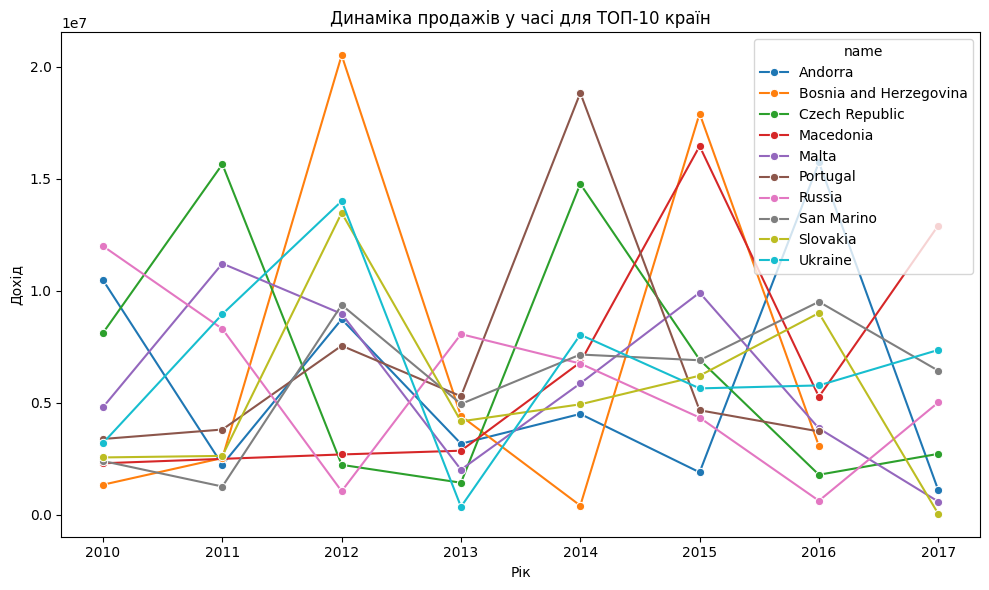

In [ ]:
top_10_countries = df.groupby("name")["Revenue"].sum().sort_values(ascending=False).head(10).index
sales_over_time_countries = df[df["name"].isin(top_10_countries)].groupby(["Year", "name"])["Revenue"].sum().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=sales_over_time_countries, x="Year", y="Revenue", hue="name", marker="o")
plt.title("Динаміка продажів у часі для ТОП-10 країн")
plt.xlabel("Рік")
plt.ylabel("Дохід")
plt.tight_layout()
plt.show()

# Найвищий показник суми доходу за весь часу був у Bosnia and Herzegovina у 2012 році

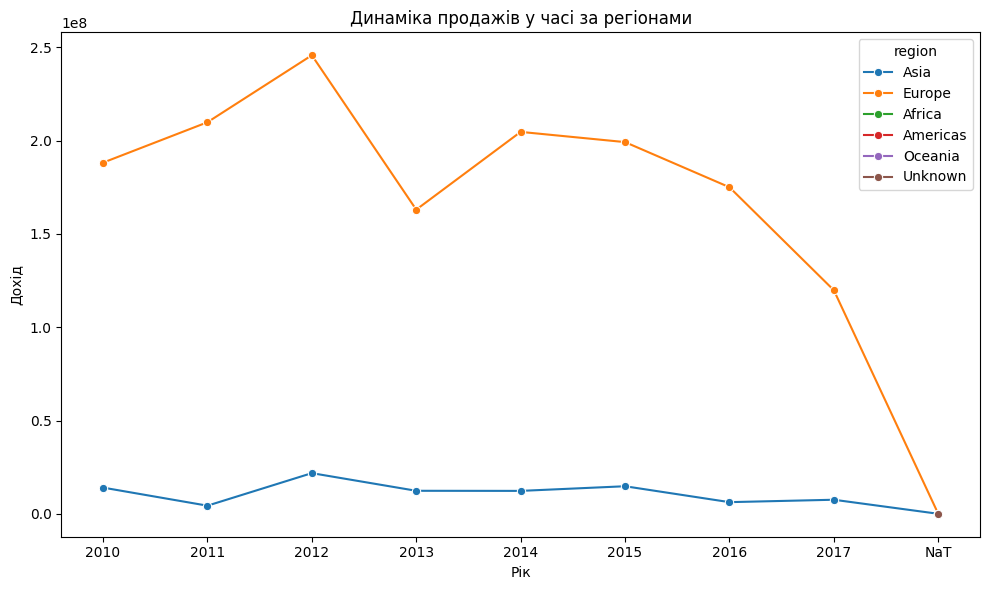

In [ ]:
sales_over_time_region = (df.groupby(["Year", "region"])["Revenue"].sum().reset_index())
plt.figure(figsize=(10,6))
sns.lineplot(data=sales_over_time_region, x="Year", y="Revenue", hue="region", marker="o")
plt.title("Динаміка продажів у часі за регіонами")
plt.xlabel("Рік")
plt.ylabel("Дохід")
plt.tight_layout()
plt.show()

# Сума доходу переважає у Європі, з 2010 до 2012 бачимо тендерцію зростання доходу, але в 2013 був спад, з 2014 дохід складав приблизно як і в 2010 році, після чого мав знову тенденцію спадання

In [ ]:
df["DayOfWeek"]= df["Order Date"].dt.day_name()

/tmp/ipython-input-2366712051.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_day, x="DayOfWeek", y="Revenue", palette=colors)
/tmp/ipython-input-2366712051.py:4: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data=sales_by_day, x="DayOfWeek", y="Revenue", palette=colors)


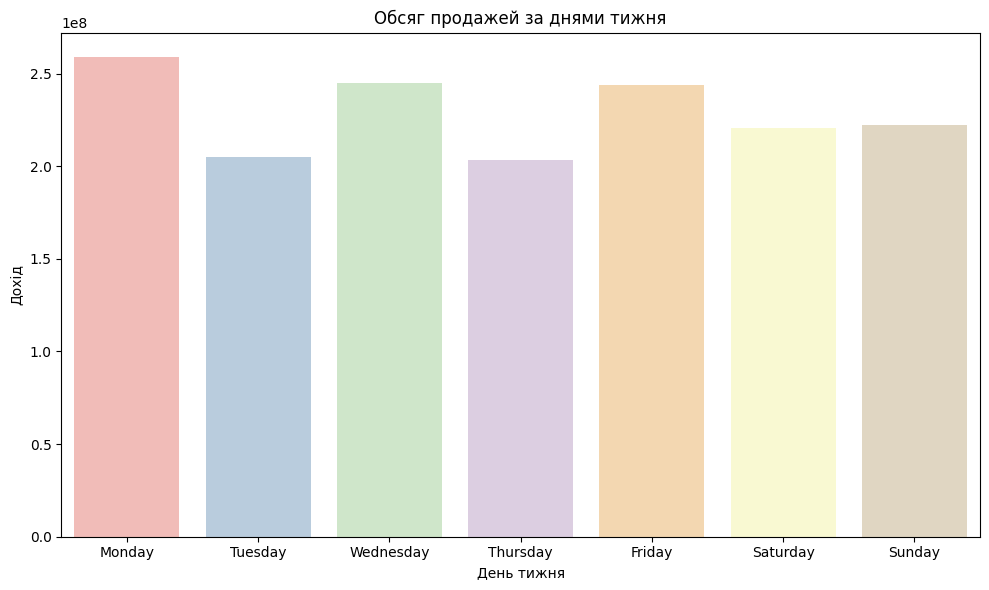

In [ ]:
plt.figure(figsize=(10,6))
sales_by_day = df.groupby("DayOfWeek")["Revenue"].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).reset_index()
colors = plt.cm.Pastel1(range(len(sales_by_day)))
sns.barplot(data=sales_by_day, x="DayOfWeek", y="Revenue", palette=colors)
plt.title("Обсяг продажей за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Дохід")
plt.tight_layout()
plt.show()

# Найбільша активність спостерігається у понеділок - в цей день продажів найбільше. Висока активність також у середу та п'ятницю

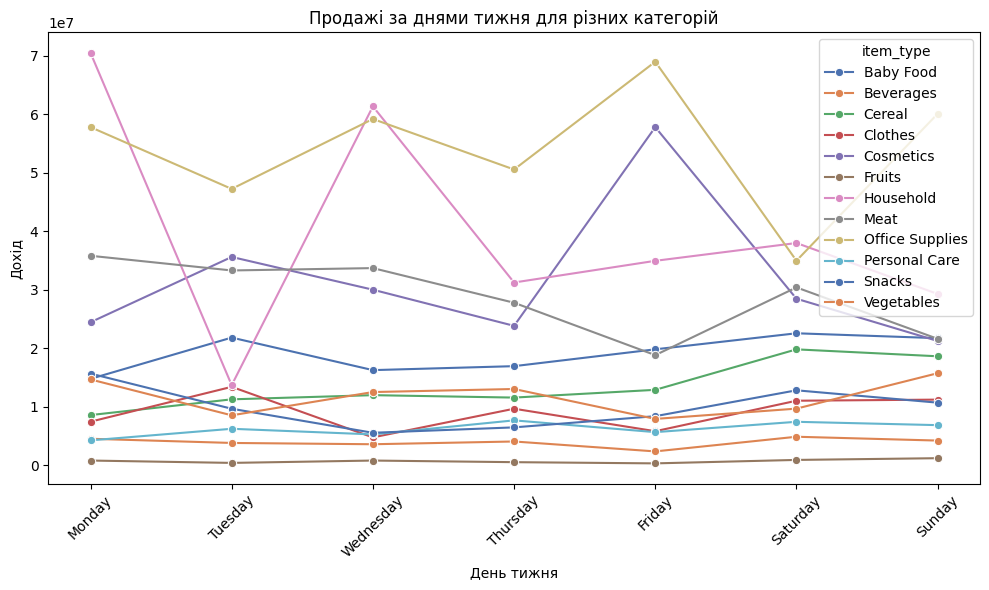

In [ ]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day_item = df.groupby(["DayOfWeek", "item_type"])["Revenue"].sum().reset_index()
sales_by_day_item["DayOfWeek"] = pd.Categorical(sales_by_day_item["DayOfWeek"],categories=days_order,ordered=True)
plt.figure(figsize=(10,6))
sns.lineplot(data=sales_by_day_item, x="DayOfWeek", y="Revenue", hue="item_type", palette="deep", marker="o")
plt.title("Продажі за днями тижня для різних категорій")
plt.xlabel("День тижня")
plt.ylabel("Дохід")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# У понеділок та середу найкраще продаються товари для дому. У п'ятницю найпопулярніші товари це товари для офісу та косметика
# Фрукти, овочі, снеки, м'ясо та товари особистого користування приносять найменший прибуток протягом цілого тижня